# Differentiate through an intermediate file

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = jnp.array([1.0, 2.0, 3.0])  # data

def f_a(x, theta):
    return x * theta**3

def f_b(y):
    return jnp.sum(y)

pipeline = lambda theta: f_b(f_a(x, theta))  # full chain

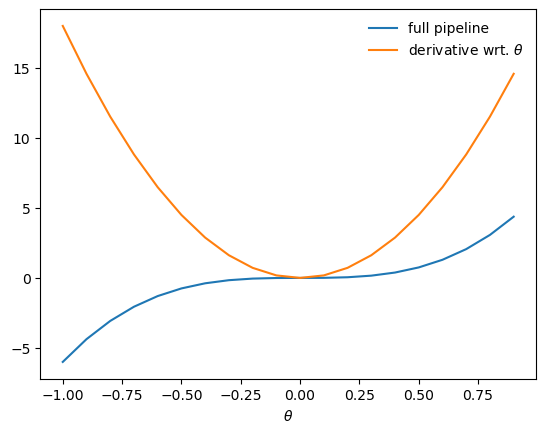

In [3]:
thetas = jnp.arange(-1, 1, 0.1)
fig, ax = plt.subplots()
ax.plot(thetas, jax.vmap(pipeline)(thetas), label="full pipeline")
ax.plot(thetas, jax.vmap(jax.grad(pipeline))(thetas), label=r"derivative wrt. $\theta$")
ax.set_xlabel(r"$\theta$")
ax.legend(frameon=False)

Lets differentiate through the full pipeline for $\theta=0.5$.

In [4]:
theta = 0.5

# gradient through full pipeline
jax.grad(pipeline)(theta)

Array(4.5, dtype=float32, weak_type=True)

Now do the same with a pipeline that goes through an intermediate file.
For a pipeline $(x, \theta)$ -`f_a`-> $y$ -`f_b`-> $z$, we get $\frac{dz}{d\theta} = \frac{\partial z}{\partial y} \cdot \frac{\partial y}{\partial \theta}$.

### Step 1: Run `f_a` forward and save to disk

In [5]:
theta = 0.5
y = f_a(x, theta)
np.savez("f_a_forward.npz", y=y)

### Step 2: Run `f_b` forward and backward, save gradient to disk

In [6]:
y_from_disk = jnp.array(np.load("f_a_forward.npz")["y"])
z = f_b(y_from_disk)
dzdy = jax.grad(f_b)(y_from_disk)  # dz/dy, where z = y1+y2+y3+...
np.savez("f_b_grad.npz", dzdy=dzdy)

### Step 3: Run `f_a` backward for final result

In [7]:
dzdy_from_disk = jnp.array(np.load("f_b_grad.npz")["dzdy"])

_, f_vjp = jax.vjp(lambda theta: f_a(x, theta), theta)  # this requires re-running step 1 forward
dz_dtheta, = f_vjp(dzdy_from_disk)
print(f"dz/dtheta at theta={theta} is {dz_dtheta}")

dz/dtheta at theta=0.5 is 4.5


In [8]:
# could also do the last step in forward mode
_, dydtheta = jax.jvp(lambda theta: f_a(x, theta), (theta,), (1.0,))  # could store this already in step 1, requiring only a dot product at the end
dz_dtheta = jnp.dot(dzdy_from_disk, dydtheta)
print(f"with forward mode for last step: {dz_dtheta}")

with forward mode for last step: 4.5


`jvp` here seems like a bad idea in general if we want to handle many different parameters $\theta$ instead of a scalar, requiring one extra forward pass of step 1 for each.